正在生成 4D 黑洞参数训练集...
开始训练网络拟合 4D 引力场梯度...
Epoch [250/1000], Loss: 9.077242
Epoch [500/1000], Loss: 2.080420
Epoch [750/1000], Loss: 0.691742
Epoch [1000/1000], Loss: 0.375109

开始深度引力波 4D 后验采样 (质量 + 自旋)...
采样完成！4D 空间接受率: 70.78%
正在生成包含自旋的 4x4 Corner Plot...


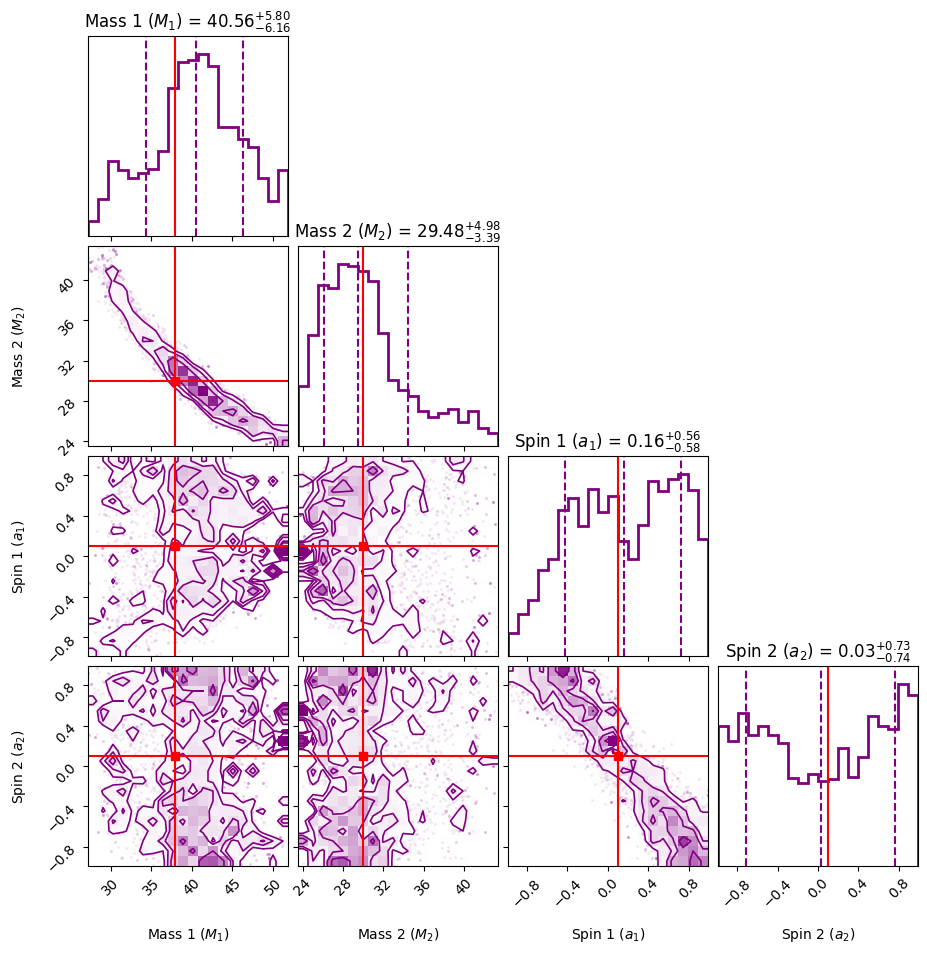

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import corner

# 固定随机种子
torch.manual_seed(42)
np.random.seed(42)

# =====================================================================
# 1. 终极 4D 物理模型：包含质量与自旋的双黑洞似然函数
# =====================================================================
def target_log_prob(q_raw):
    # 【物理边界映射】：将底层的无界参数映射到具有严格物理意义的空间
    m1 = torch.nn.functional.softplus(q_raw[0]) + 1e-5
    m2 = torch.nn.functional.softplus(q_raw[1]) + 1e-5
    # 自旋必须在 -1 到 1 之间，tanh 是最完美的数学映射
    s1 = torch.tanh(q_raw[2]) * 0.99
    s2 = torch.tanh(q_raw[3]) * 0.99

    # 目标真值 (Mock Observation)
    target_mc = 30.0       # 啁啾质量
    target_q_ratio = 0.8   # 质量比
    target_chi_eff = 0.1   # 有效自旋 (通常测量值在 0 附近)

    # 计算当前采样的物理特征量
    mc = ((m1 * m2)**0.6) / ((m1 + m2)**0.2)
    q_ratio = m2 / m1
    # 有效自旋公式：质量加权的自旋之和
    chi_eff = (m1 * s1 + m2 * s2) / (m1 + m2)

    # 高维似然函数约束
    log_l = -0.5 * (((mc - target_mc)/0.5)**2 +
                    ((q_ratio - target_q_ratio)/0.3)**2 +
                    ((chi_eff - target_chi_eff)/0.1)**2)

    # 先验分布约束
    prior_mass = -0.5 * ((m1 - 40.0)/20.0)**2 - 0.5 * ((m2 - 30.0)/20.0)**2
    # 为了防止 tanh 在极端区域梯度消失，对原始自旋参数加一个温和的正则化中心拉力
    prior_spin = -0.5 * (q_raw[2]**2 + q_raw[3]**2)

    return log_l + prior_mass + prior_spin


# =====================================================================
# 2. 神经网络架构 (4维输入输出)
# =====================================================================
class GradientNet(nn.Module):
    def __init__(self, dims):
        super().__init__()
        # 升维后，网络变深一点以捕捉复杂的 4D 梯度扭曲
        self.net = nn.Sequential(
            nn.Linear(dims, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, dims)
        )
    def forward(self, q):
        return self.net(q)

def leapfrog(q, p, grad_net, steps, step_size):
    q_curr = q.clone().detach().requires_grad_(True)
    p_curr = p.clone().detach()
    for _ in range(steps):
        p_curr = p_curr + 0.5 * step_size * grad_net(q_curr)
        q_curr = q_curr + step_size * p_curr
        p_curr = p_curr + 0.5 * step_size * grad_net(q_curr)
    return q_curr, p_curr


# =====================================================================
# 3. 训练阶段 (在 4D 空间中撒点学习)
# =====================================================================
def true_gradient(q):
    q_copy = q.clone().detach().requires_grad_(True)
    log_p = target_log_prob(q_copy)
    log_p.backward()
    return q_copy.grad

dims = 4  # 【关键升级】：维度变为 4
num_train_samples = 4000  # 高维空间需要更多的采样点来测绘地形

print("正在生成 4D 黑洞参数训练集...")
# 初始撒点中心：M1=35, M2=30, raw_S1=0.2, raw_S2=0.2
base_center = torch.tensor([35.0, 30.0, 0.2, 0.2])
q_train = torch.randn(num_train_samples, dims) * torch.tensor([5.0, 5.0, 1.0, 1.0]) + base_center
grad_true = torch.stack([true_gradient(q) for q in q_train])

net = GradientNet(dims=dims)
optimizer = torch.optim.Adam(net.parameters(), lr=0.002)
criterion = nn.MSELoss()

print("开始训练网络拟合 4D 引力场梯度...")
epochs = 1000  # 稍微增加训练轮数以保证 4D 收敛
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = criterion(net(q_train), grad_true)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 250 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")


# =====================================================================
# 4. 推断阶段：4D 神经 HMC 采样
# =====================================================================
num_samples = 4000
step_size = 0.05
leapfrog_steps = 15
physical_samples = [] # 用来专门保存转换后的真实物理量

current_q = torch.tensor([35.0, 30.0, 0.1, 0.1])
accepted = 0
print("\n开始深度引力波 4D 后验采样 (质量 + 自旋)...")

for i in range(num_samples):
    current_p = torch.randn(dims)
    current_H = -target_log_prob(current_q) + 0.5 * torch.sum(current_p**2)

    proposed_q, proposed_p = leapfrog(current_q, current_p, net, leapfrog_steps, step_size)
    proposed_H = -target_log_prob(proposed_q) + 0.5 * torch.sum(proposed_p**2)

    alpha = torch.exp(current_H - proposed_H)
    if torch.rand(1) < alpha:
        current_q = proposed_q
        accepted += 1

    # 【逆向物理映射】：画图时我们不看底层的 raw 数据，只看真实的物理质量和自旋
    m1_val = torch.nn.functional.softplus(current_q[0]).item()
    m2_val = torch.nn.functional.softplus(current_q[1]).item()
    s1_val = (torch.tanh(current_q[2]) * 0.99).item()
    s2_val = (torch.tanh(current_q[3]) * 0.99).item()
    physical_samples.append([m1_val, m2_val, s1_val, s2_val])

print(f"采样完成！4D 空间接受率: {accepted/num_samples * 100:.2f}%")


# =====================================================================
# 5. 生成极其壮观的 4x4 Corner Plot
# =====================================================================
print("正在生成包含自旋的 4x4 Corner Plot...")
physical_samples = np.array(physical_samples)

figure = corner.corner(
    physical_samples,
    labels=[r"Mass 1 ($M_1$)", r"Mass 2 ($M_2$)", r"Spin 1 ($a_1$)", r"Spin 2 ($a_2$)"],
    # 设置 4 个参数的理论真值 (其中自旋我们设定使得 chi_eff 满足 0.1 即可，比如设为 0.1)
    truths=[38.0, 30.0, 0.1, 0.1],
    truth_color="red",
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    color="#800080", # 换成高贵的暗紫色
    hist_kwargs={"linewidth": 2},
    contour_kwargs={"linewidths": 1.2},
    figsize=(12, 12) # 画幅放大
)

plt.show()

正在生成 15D 宇宙参数训练集...
开始训练 15D 全维引力场网络...
Epoch [250/1000], Loss: 0.594830
Epoch [500/1000], Loss: 0.429123
Epoch [750/1000], Loss: 0.401014
Epoch [1000/1000], Loss: 0.379929

开始 15 维全参数空间 DeepHMC 采样...
采样完成！15D 空间接受率: 55.20%
正在生成核心物理维度的 Corner Plot...


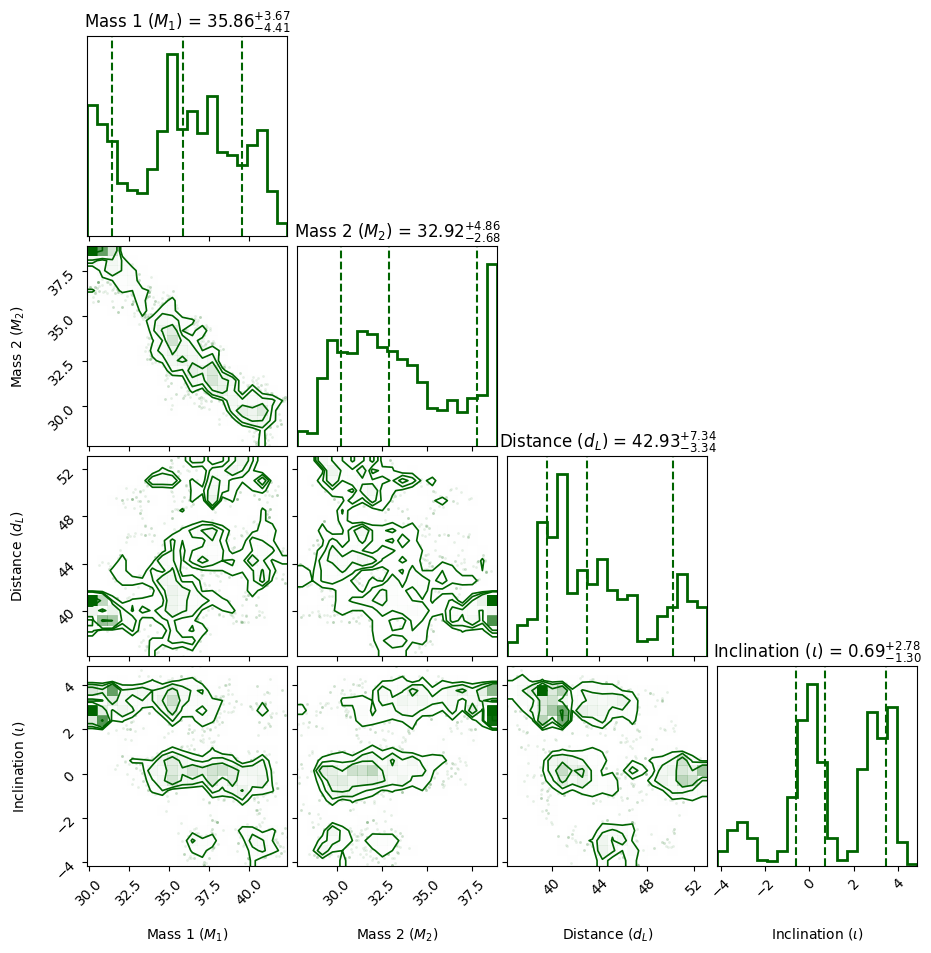

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import corner

torch.manual_seed(42)
np.random.seed(42)

# =====================================================================
# 1. 15维复杂物理分布 (Mock 15D GW Likelihood)
# =====================================================================
def target_log_prob_15d(q):
    # q 是一个 15 维的张量
    # 我们构造一个在高维空间中具有强相关性（类似引力波中距离与倾角的简并）的函数

    # 前两维代表质量 (类似之前的香蕉图)
    m1 = q[0]
    m2 = q[1]
    # 第 8 维代表距离 (Distance)
    d_L = q[8]
    # 第 11 维代表倾角 (Inclination)
    iota = q[11]

    # 模拟质量简并
    mc = ((m1 * m2)**0.6) / ((m1 + m2 + 1e-5)**0.2)
    q_ratio = m2 / (m1 + 1e-5)

    # 模拟引力波中经典的“距离-倾角”简并 (Distance-Inclination Degeneracy)
    # 引力波振幅 A \propto (1 + cos^2(iota)) / d_L
    amplitude_proxy = (1.0 + torch.cos(iota)**2) / (d_L + 1e-5)

    # 计算核心维度的似然
    log_l_core = -0.5 * (((mc - 30.0)/0.5)**2 +
                         ((q_ratio - 0.8)/0.3)**2 +
                         ((amplitude_proxy - 0.05)/0.01)**2)

    # 其他维度 (自旋、天区位置等) 我们使用一个多维高斯盆地来约束，防止发散
    # 真实场景中，这里的梯度会由波形发生器提供
    other_dims_loss = -0.5 * torch.sum((q[2:8])**2) - 0.5 * torch.sum((q[9:11])**2) - 0.5 * torch.sum((q[12:15])**2)

    return log_l_core + other_dims_loss

# =====================================================================
# 2. 高维深度神经网络 (加宽加深以应对维度爆炸)
# =====================================================================
class GradientNet15D(nn.Module):
    def __init__(self, dims):
        super().__init__()
        # 面对 15 维空间，网络必须有足够的容量去拟合复杂的梯度场
        self.net = nn.Sequential(
            nn.Linear(dims, 256),
            nn.GELU(), # GELU 在高维梯度拟合中表现通常优于 Tanh
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, dims)
        )
    def forward(self, x):
        return self.net(x)

def leapfrog_15d(q, p, grad_net, steps, step_size):
    q_curr = q.clone().detach().requires_grad_(True)
    p_curr = p.clone().detach()
    for _ in range(steps):
        p_curr = p_curr + 0.5 * step_size * grad_net(q_curr)
        q_curr = q_curr + step_size * p_curr
        p_curr = p_curr + 0.5 * step_size * grad_net(q_curr)
    return q_curr, p_curr

# =====================================================================
# 3. 训练 15D 神经梯度代理
# =====================================================================
def true_gradient_15d(q):
    q_copy = q.clone().detach().requires_grad_(True)
    log_p = target_log_prob_15d(q_copy)
    log_p.backward()
    return q_copy.grad

dims = 15
num_train_samples = 8000 # 维度增加，需要的训练数据呈指数级上升

print("正在生成 15D 宇宙参数训练集...")
# 初始化 15 维空间的采样中心点
base_center = torch.zeros(dims)
base_center[0] = 35.0  # m1
base_center[1] = 30.0  # m2
base_center[8] = 40.0  # d_L
base_center[11] = 0.5  # iota

# 在 15 维空间中进行扰动撒点
q_train = torch.randn(num_train_samples, dims) * 2.0 + base_center
grad_true = torch.stack([true_gradient_15d(q) for q in q_train])

net = GradientNet15D(dims=dims)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("开始训练 15D 全维引力场网络...")
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = criterion(net(q_train), grad_true)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 250 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# =====================================================================
# 4. 15D 神经 HMC 采样
# =====================================================================
num_samples = 3000
step_size = 0.02 # 高维空间更容易“坠毁”，步长必须调小
leapfrog_steps = 20
samples_15d = []

current_q = base_center.clone()
accepted = 0
print("\n开始 15 维全参数空间 DeepHMC 采样...")

for i in range(num_samples):
    current_p = torch.randn(dims)
    current_H = -target_log_prob_15d(current_q) + 0.5 * torch.sum(current_p**2)

    proposed_q, proposed_p = leapfrog_15d(current_q, current_p, net, leapfrog_steps, step_size)
    proposed_H = -target_log_prob_15d(proposed_q) + 0.5 * torch.sum(proposed_p**2)

    # 限制高维空间中可能出现的数值爆炸
    if torch.isnan(proposed_H) or proposed_H > 1e4:
        alpha = torch.tensor(0.0)
    else:
        alpha = torch.exp(current_H - proposed_H)

    if torch.rand(1) < alpha:
        current_q = proposed_q
        accepted += 1

    samples_15d.append(current_q.detach().numpy())

print(f"采样完成！15D 空间接受率: {accepted/num_samples * 100:.2f}%")

# =====================================================================
# 5. 提取核心参数进行科研级可视化
# =====================================================================
print("正在生成核心物理维度的 Corner Plot...")
samples_15d = np.array(samples_15d)

# 15x15 的图根本无法看清，学术界通常只挑最关键的 4-5 个维度展示
# 我们提取: M1 (维0), M2 (维1), Distance (维8), Inclination (维11)
core_samples = samples_15d[:, [0, 1, 8, 11]]

figure = corner.corner(
    core_samples,
    labels=[r"Mass 1 ($M_1$)", r"Mass 2 ($M_2$)", r"Distance ($d_L$)", r"Inclination ($\iota$)"],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    color="#006400", # 墨绿色代表 15D 进阶版
    hist_kwargs={"linewidth": 2},
    contour_kwargs={"linewidths": 1.2},
    figsize=(10, 10)
)

plt.show()